# Brain/head reconstruction comparison

This notebook reproduces the brain/head reconstruction comparison figure. It compares BART NLINV/ENLIVE-style reconstructions with the proposed lifted \(\ell_{1,2}\) reconstruction for acceleration factors \(R=4,7,8.5\).

The head/brain data are adapted from the ENLIVE reproducibility repository, specifically the `08_09_lowrank/head_slice1` experiment.

Before running this notebook, generate the reconstruction outputs using:

- `exp/Exp3_realdata.m` for the proposed method;
- `exp/exp2_NLINV_brain.ipynb` for the BART NLINV baseline.

Required files:
- `output/brain/ENLIVE_brain.mat`
- `output/brain/my_recon_US4.mat`
- `output/brain/my_recon_US7.mat`
- `output/brain/my_recon_US8.5.mat`
- `data/brain/pat_4.mat`, `pat_7.mat`, `pat_8.5.mat`

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

In [38]:
from PIL import Image

def disp(im,clip = False,figsize=(4,4)): # to avoid code repetition
    pixvals = abs(np.squeeze(im))
    if clip == True:
        minval = np.percentile(pixvals, 2) #some values are close to zero, clip it out for higher contrast
        maxval = np.percentile(pixvals, 98)
    else:
        minval = np.percentile(pixvals, 0) #some values are close to zero, clip it out for higher contrast
        maxval = np.percentile(pixvals, 100)
    pixvals = np.clip(pixvals, minval, maxval)
    pixvals = ((pixvals - minval) / (maxval - minval)) * 255
    img = Image.fromarray(pixvals.astype(np.uint8))
    return img

In [42]:
images = []

Load ENLIVE results

In [ ]:
from scipy.io import loadmat
ENLIVE = loadmat('../output/brain/ENLIVE_brain.mat')

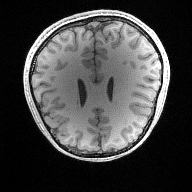

In [ ]:
images.append(disp(ENLIVE['brain_4'],True))
disp(ENLIVE['brain_4'],True)

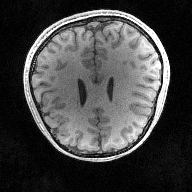

In [ ]:
images.append(disp(ENLIVE['brain_7'],True))
disp(ENLIVE['brain_7'],True)

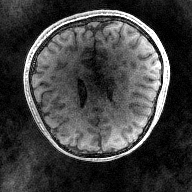

In [ ]:
images.append(disp(ENLIVE['brain_8.5'],True))
disp(ENLIVE['brain_8.5'],True)

In [ ]:
my_recon_4 = loadmat('../output/brain/my_recon_US4.mat')
my_recon_4  = my_recon_4['recon']
my_recon_7 = loadmat('../output/brain/my_recon_US7.mat')
my_recon_7 = my_recon_7['recon']
my_recon_8p5 = loadmat('../output/brain/my_recon_US8.5.mat')
my_recon_8p5 = my_recon_8p5['recon']

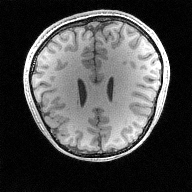

In [48]:
images.append(disp(my_recon_4,True))
disp(my_recon_4,True)

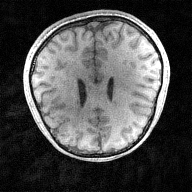

In [49]:
images.append(disp(my_recon_7,True))
disp(my_recon_7,True)

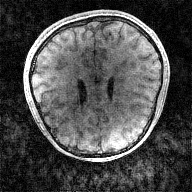

In [ ]:
images.append(disp(my_recon_8p5,True))
disp(my_recon_8p5,True)

Load sampling patterns

In [ ]:
pat_4 = loadmat('../data/brain/pat_4.mat')
pat_4 = pat_4['poisson_mask']
pat_7 = loadmat('../data/brain/pat_7.mat')
pat_7 = pat_7['poisson_mask']
pat_805 = loadmat('../data/brain/pat_8.5.mat')
pat_805 = pat_805['poisson_mask']

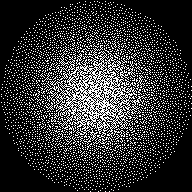

In [51]:
images.append(disp(pat_4))
disp(pat_4)

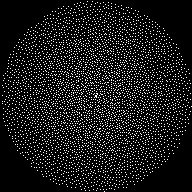

In [52]:
images.append(disp(pat_7))
disp(pat_7)

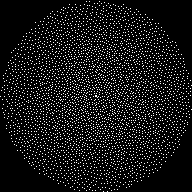

In [53]:
images.append(disp(pat_805))
disp(pat_805)

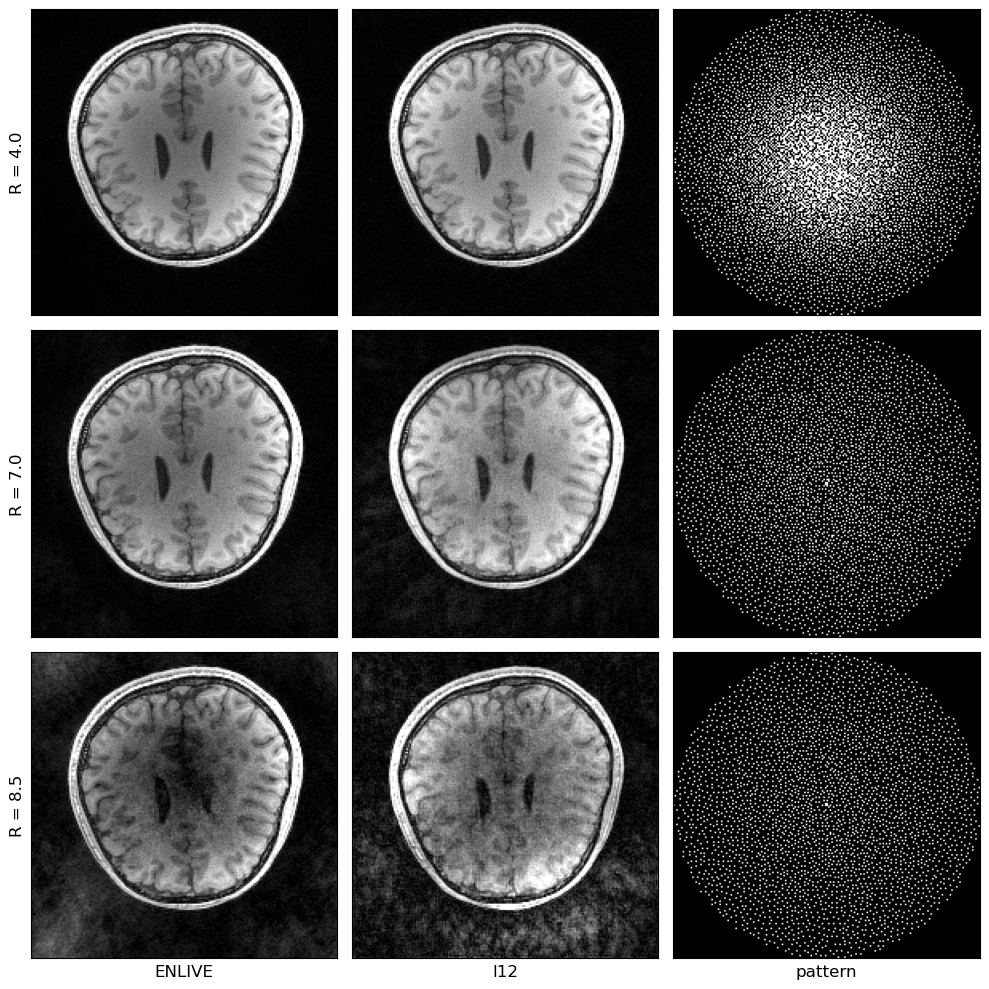

In [58]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Labels for the axes
x_labels = [ 'ENLIVE', 'l12', 'pattern']
y_labels = ['R = 4.0', 'R = 7.0', 'R = 8.5']

# Plot each array in the grid
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.imshow(images[i + 3*j], cmap='gray')  # Adjust cmap as needed
        ax.set_xticks([])  # Hide x ticks but keep labels
        ax.set_yticks([])  # Hide y ticks but keep labels

# Set x-axis labels for the bottom row
for ax, label in zip(axes[-1], x_labels):
    ax.set_xlabel(label, fontsize=12)

# Set y-axis labels for the leftmost column
for ax, label in zip(axes[:, 0], y_labels):
    ax.set_ylabel(label, fontsize=12, rotation=90)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()